In [0]:
import pandas as pd
import numpy as np
import datetime
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error
import plotly.express as px
import plotly.graph_objects as go

In [0]:
input_path = '/dbfs/mnt/thesis/predictions/'

### Benchmark

predictions_2010-08-01.csv
predictions_2010-08-02.csv
predictions_2010-08-03.csv
predictions_2010-08-04.csv
predictions_2010-08-05.csv
predictions_2010-08-06.csv
predictions_2010-08-07.csv
predictions_2010-08-08.csv
predictions_2010-08-09.csv
predictions_2010-08-10.csv
predictions_2010-08-11.csv
predictions_2010-08-12.csv
predictions_2010-08-13.csv
predictions_2010-08-14.csv
predictions_2010-08-15.csv
predictions_2010-08-16.csv
predictions_2010-08-17.csv
predictions_2010-08-18.csv
predictions_2010-08-19.csv
predictions_2010-08-20.csv
predictions_2010-08-21.csv
predictions_2010-08-22.csv
predictions_2010-08-23.csv
predictions_2010-08-24.csv
predictions_2010-08-25.csv
predictions_2010-08-26.csv
predictions_2010-08-27.csv
predictions_2010-08-28.csv
(1548288, 4)
Out[3]:

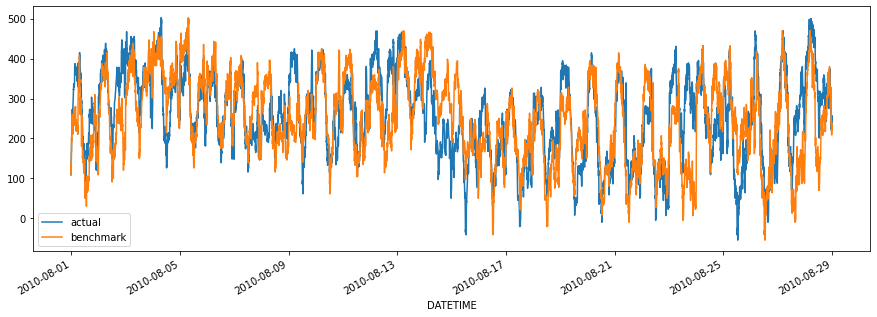

<AxesSubplot:xlabel='DATETIME'>

In [0]:
bm_pred = pd.DataFrame()

bm_pred_list = os.listdir(input_path + 'benchmark/')
bm_pred_list = [x for x in bm_pred_list if x.startswith('predictions_2010-08')]

for i in bm_pred_list:
    print(i)
    curr_pred = pd.read_csv(input_path + 'benchmark/' + i,parse_dates=['DATETIME'])
    curr_pred = curr_pred[['DATETIME','LOCATION','VALUE','bm_1d_prediction']].rename(columns={
        'bm_1d_prediction':'benchmark',
        'VALUE':'actual'
    })
    bm_pred = pd.concat([curr_pred, bm_pred], ignore_index=True)

print(bm_pred.shape)
bm_pred[bm_pred['LOCATION']==0].plot(x='DATETIME', y=['actual', 'benchmark'], figsize=(15,5))

### LGBM

In [0]:
# lgbm_pred_no_retrain = pd.DataFrame()

# lgbm_pred_list = os.listdir(input_path + 'lgbm/ensemble_rolling_no_retrain/')
# lgbm_pred_list = [x for x in lgbm_pred_list if x.startswith('predictions_2010-08')]

# for i in lgbm_pred_list:
#     print(i)
#     curr_pred = pd.read_csv(input_path + 'lgbm/ensemble_rolling_no_retrain/' + i,parse_dates=['DATETIME'])
#     curr_pred = curr_pred[['DATETIME','LOCATION','PREDICTED']].rename(columns={
#         'PREDICTED':'lgbm_no_retrain'
#     })
#     lgbm_pred_no_retrain = pd.concat([curr_pred, lgbm_pred_no_retrain], ignore_index=True)

# print(lgbm_pred_no_retrain.shape)
# lgbm_pred_no_retrain[lgbm_pred_no_retrain['LOCATION']==0].plot(x='DATETIME', y=['lgbm_no_retrain'], figsize=(15,5))

predictions_2010-08-01.csv
predictions_2010-08-02.csv
predictions_2010-08-03.csv
predictions_2010-08-04.csv
predictions_2010-08-05.csv
predictions_2010-08-06.csv
predictions_2010-08-07.csv
predictions_2010-08-08.csv
predictions_2010-08-09.csv
predictions_2010-08-10.csv
predictions_2010-08-11.csv
predictions_2010-08-12.csv
predictions_2010-08-13.csv
predictions_2010-08-14.csv
(193536, 3)
Out[5]:

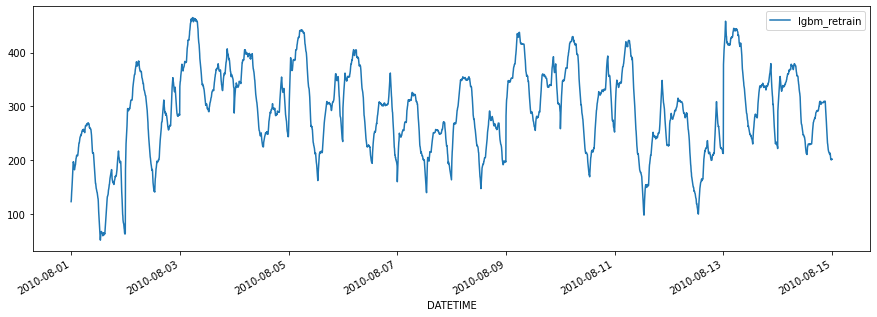

<AxesSubplot:xlabel='DATETIME'>

In [0]:
lgbm_pred_retrain = pd.DataFrame()

lgbm_pred_list = os.listdir(input_path + 'lgbm/ensemble_rolling/')
lgbm_pred_list = [x for x in lgbm_pred_list if x.startswith('predictions_2010-08')]

for i in lgbm_pred_list:
    print(i)
    curr_pred = pd.read_csv(input_path + 'lgbm/ensemble_rolling/' + i,parse_dates=['DATETIME'])
    curr_pred = curr_pred[['DATETIME','LOCATION','PREDICTED']].rename(columns={
        'PREDICTED':'lgbm_retrain'
    })
    lgbm_pred_retrain = pd.concat([curr_pred, lgbm_pred_retrain], ignore_index=True)

print(lgbm_pred_retrain.shape)
lgbm_pred_retrain[lgbm_pred_retrain['LOCATION']==0].plot(x='DATETIME', y=['lgbm_retrain'], figsize=(15,5))

predictions_2010-08-08.csv
predictions_2010-08-09.csv
predictions_2010-08-10.csv
predictions_2010-08-11.csv
predictions_2010-08-12.csv
predictions_2010-08-13.csv
predictions_2010-08-14.csv
(193536, 3)
Out[6]:

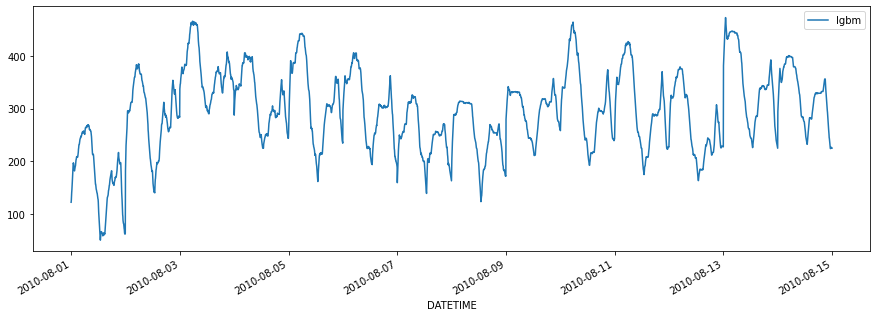

<AxesSubplot:xlabel='DATETIME'>

In [0]:
lgbm_pred_weekly_retune = lgbm_pred_retrain[lgbm_pred_retrain['DATETIME'] < "2010-08-08"].copy(deep=True).rename(columns={
    'lgbm_retrain':'lgbm'
})

lgbm_pred_list = os.listdir(input_path + 'lgbm/ensemble_rolling_weekly_retune/')
lgbm_pred_list = [x for x in lgbm_pred_list if x.startswith('predictions_2010-08')]

for i in lgbm_pred_list:
    print(i)
    curr_pred = pd.read_csv(input_path + 'lgbm/ensemble_rolling_weekly_retune/' + i,parse_dates=['DATETIME'])
    curr_pred = curr_pred[['DATETIME','LOCATION','PREDICTED']].rename(columns={
        'PREDICTED':'lgbm'
    })
    lgbm_pred_weekly_retune = pd.concat([curr_pred, lgbm_pred_weekly_retune], ignore_index=True)

print(lgbm_pred_weekly_retune.shape)
lgbm_pred_weekly_retune[lgbm_pred_weekly_retune['LOCATION']==0].plot(x='DATETIME', y=['lgbm'], figsize=(15,5))

In [0]:
# lgbm_pred_periodic_retune = pd.DataFrame()

# lgbm_pred_list = os.listdir(input_path + 'lgbm/ensemble_rolling_periodic_retune/')
# lgbm_pred_list = [x for x in lgbm_pred_list if x.startswith('predictions_2010-08')]

# for i in lgbm_pred_list:
#     print(i)
#     curr_pred = pd.read_csv(input_path + 'lgbm/ensemble_rolling_periodic_retune/' + i,parse_dates=['DATETIME'])
#     curr_pred = curr_pred[['DATETIME','LOCATION','PREDICTED']].rename(columns={
#         'PREDICTED':'lgbm_periodic_retune'
#     })
#     lgbm_pred_periodic_retune = pd.concat([curr_pred, lgbm_pred_periodic_retune], ignore_index=True)

# print(lgbm_pred_weekly_retune.shape)
# lgbm_pred_periodic_retune[lgbm_pred_periodic_retune['LOCATION']==0].plot(x='DATETIME', y=['lgbm_periodic_retune'], figsize=(15,5))

### NHITS

In [0]:
# nhits_pred_no_retrain = pd.DataFrame()

# nhits_pred_list = os.listdir(input_path + 'nhits/basic_no_retrain/')
# nhits_pred_list = [x for x in nhits_pred_list if x.startswith('predictions_2010-08')]

# for i in nhits_pred_list:
#     print(i)
#     curr_pred = pd.read_csv(input_path + 'nhits/basic_no_retrain/' + i,parse_dates=['DATETIME'])
#     curr_pred = curr_pred[['DATETIME','LOCATION','NHITS']].rename(columns={
#         'NHITS':'nhits_no_retrain'
#     })
#     nhits_pred_no_retrain = pd.concat([curr_pred, nhits_pred_no_retrain], ignore_index=True)

# print(nhits_pred_no_retrain.shape)
# nhits_pred_no_retrain[nhits_pred_no_retrain['LOCATION']==0].plot(x='DATETIME', y=['nhits_no_retrain'], figsize=(15,5))

predictions_2010-08-01.csv
predictions_2010-08-02.csv
predictions_2010-08-03.csv
predictions_2010-08-04.csv
predictions_2010-08-05.csv
predictions_2010-08-06.csv
predictions_2010-08-07.csv
predictions_2010-08-08.csv
predictions_2010-08-09.csv
predictions_2010-08-10.csv
predictions_2010-08-11.csv
predictions_2010-08-12.csv
predictions_2010-08-13.csv
predictions_2010-08-14.csv
(193536, 3)
Out[9]:

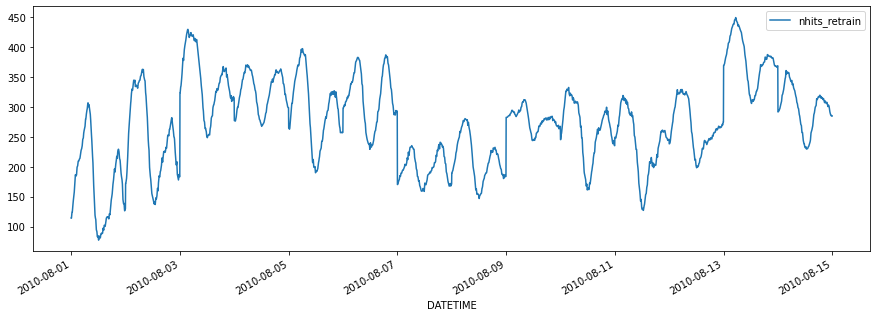

<AxesSubplot:xlabel='DATETIME'>

In [0]:
nhits_pred_retrain = pd.DataFrame()

nhits_pred_list = os.listdir(input_path + 'nhits/basic')
nhits_pred_list = [x for x in nhits_pred_list if x.startswith('predictions_2010-08')]

for i in nhits_pred_list:
    print(i)
    curr_pred = pd.read_csv(input_path + 'nhits/basic/' + i,parse_dates=['DATETIME'])
    curr_pred = curr_pred[['DATETIME','LOCATION','NHITS']].rename(columns={
        'NHITS':'nhits_retrain'
    })
    nhits_pred_retrain = pd.concat([curr_pred, nhits_pred_retrain], ignore_index=True)

print(nhits_pred_retrain.shape)
nhits_pred_retrain[nhits_pred_retrain['LOCATION']==0].plot(x='DATETIME', y=['nhits_retrain'], figsize=(15,5))

predictions_2010-08-08.csv
predictions_2010-08-09.csv
predictions_2010-08-10.csv
predictions_2010-08-11.csv
predictions_2010-08-12.csv
predictions_2010-08-13.csv
predictions_2010-08-14.csv
(193536, 3)
Out[10]:

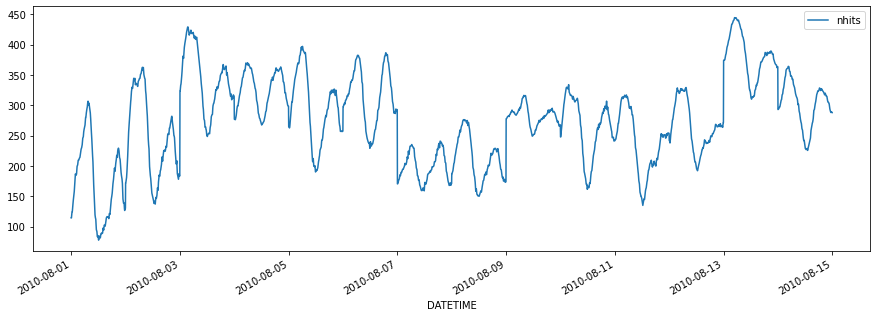

<AxesSubplot:xlabel='DATETIME'>

In [0]:
nhits_pred_weekly_retune = nhits_pred_retrain[nhits_pred_retrain['DATETIME'] < "2010-08-08"].copy(deep=True).rename(columns={
    'nhits_retrain':'nhits'
})

nhits_pred_list = os.listdir(input_path + 'nhits/basic_weekly_retune')
nhits_pred_list = [x for x in nhits_pred_list if x.startswith('predictions_2010-08')]

for i in nhits_pred_list:
    print(i)
    curr_pred = pd.read_csv(input_path + 'nhits/basic_weekly_retune/' + i,parse_dates=['DATETIME'])
    curr_pred = curr_pred[['DATETIME','LOCATION','NHITS']].rename(columns={
        'NHITS':'nhits'
    })
    nhits_pred_weekly_retune = pd.concat([curr_pred, nhits_pred_weekly_retune], ignore_index=True)

print(nhits_pred_weekly_retune.shape)
nhits_pred_weekly_retune[nhits_pred_weekly_retune['LOCATION']==0].plot(x='DATETIME', y=['nhits'], figsize=(15,5))

In [0]:
# nhits_pred_periodic_retune = pd.DataFrame()

# nhits_pred_list = os.listdir(input_path + 'nhits/basic_periodic_retune')
# nhits_pred_list = [x for x in nhits_pred_list if x.startswith('predictions_2010-08')]

# for i in nhits_pred_list:
#     print(i)
#     curr_pred = pd.read_csv(input_path + 'nhits/basic_periodic_retune/' + i,parse_dates=['DATETIME'])
#     curr_pred = curr_pred[['DATETIME','LOCATION','NHITS']].rename(columns={
#         'NHITS':'nhits_periodic_retune'
#     })
#     nhits_pred_periodic_retune = pd.concat([curr_pred, nhits_pred_periodic_retune], ignore_index=True)

# print(nhits_pred_periodic_retune.shape)
# nhits_pred_periodic_retune[nhits_pred_periodic_retune['LOCATION']==0].plot(x='DATETIME', y=['nhits_periodic_retune'], figsize=(15,5))

### Eval

In [0]:
eval_df = bm_pred.merge(
    lgbm_pred_weekly_retune[['DATETIME','LOCATION','lgbm']], on=['DATETIME','LOCATION'], how='inner', validate='1:1'
).merge(
    nhits_pred_weekly_retune[['DATETIME','LOCATION','nhits']], on=['DATETIME','LOCATION'], how='inner', validate='1:1'
)

In [0]:
eval_df = eval_df[eval_df['LOCATION'] < 48]
eval_df = eval_df[eval_df['DATETIME'] < "2010-08-15"]
eval_df = eval_df.sort_values(by=['LOCATION','DATETIME'])
eval_df = eval_df[eval_df['LOCATION'].isin(bad_list) == False]


print(eval_df.shape)
print("Shutdown rows len:", len(eval_df[eval_df['actual'] == 0]))
print("Shutdown rows %:", len(eval_df[eval_df['actual'] == 0]) / len(eval_df))
eval_df = eval_df[eval_df['actual'] != 0]
print(eval_df.shape)
eval_df.head(3)

(60480, 6)
Shutdown rows len: 5665
Shutdown rows %: 0.09366732804232804
(54815, 6)
Out[14]:

,DATETIME,LOCATION,actual,benchmark,lgbm,nhits
180000,2010-08-01 00:00:00,1,-243.66,-269.97,-268.792052,-285.81410
180001,2010-08-01 00:05:00,1,-202.03,-270.47,-246.929059,-285.81410
180002,2010-08-01 00:10:00,1,-186.98,-248.91,-228.708885,-283.17645


In [0]:

def plot_predictions(location):
    filtered_df = eval_df[eval_df['LOCATION'] == location]

    fig = go.Figure()

    fig.add_trace(go.Scatter(x=filtered_df['DATETIME'], y=filtered_df['actual'], mode='lines', name='actual'))
    fig.add_trace(go.Scatter(x=filtered_df['DATETIME'], y=filtered_df['benchmark'], mode='lines', name='benchmark'))
    fig.add_trace(go.Scatter(x=filtered_df['DATETIME'], y=filtered_df['lgbm'], mode='lines', name='lgbm'))
    fig.add_trace(go.Scatter(x=filtered_df['DATETIME'], y=filtered_df['nhits'], mode='lines', name='nhits'))

    fig.update_layout(
        title=f'Time Series Predictions for Location {location}',
        xaxis_title='Datetime',
        yaxis_title='Prediction'
    )

    fig.show()

In [0]:
plot_predictions(43)

### Eval

In [0]:
model_cols = ['benchmark', 'lgbm', 'nhits']

In [0]:
def _prepare_long_df(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:
 
    df_long = (
        df.melt(
            id_vars=['DATETIME', 'LOCATION', 'actual'],
            value_vars=model_cols,
            var_name='MODEL',
            value_name='forecast'
        )
        .assign(
            error=lambda d: d['forecast'] - d['actual'],
            abs_error=lambda d: d['error'].abs(),
            sq_error=lambda d: d['error'] ** 2,
            DATE=lambda d: d['DATETIME'].dt.date
        )
    )
    return df_long

def compute_5_min_errors(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:

    df_long = _prepare_long_df(df, model_cols)
    df_5min = (
        df_long
        .assign(
            MAE=df_long['abs_error'],
            NMAE=df_long['abs_error'] / df_long['actual'].abs(),
            RMSE=df_long['sq_error'],
            TAE=df_long['abs_error']
        )
        [['DATETIME', 'LOCATION', 'MODEL', 'MAE', 'NMAE', 'RMSE', 'TAE']]
    )
    return df_5min


def compute_date_location_level_errors(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:

    df_long = _prepare_long_df(df, model_cols)
    def agg(group):
        mae = group['abs_error'].mean()
        rmse = np.sqrt(group['sq_error'].mean())
        tae = group['abs_error'].sum()
        mean_abs_act = group['actual'].abs().mean()
        nmae = mae / mean_abs_act if mean_abs_act != 0 else np.nan
        return pd.Series({'MAE': mae, 'NMAE': nmae, 'RMSE': rmse, 'TAE': tae})
    return df_long.groupby(['DATE', 'LOCATION', 'MODEL']).apply(agg).reset_index()


def compute_date_model_level_errors(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:

    df_long = _prepare_long_df(df, model_cols)
    def agg(group):
        mae = group['abs_error'].mean()
        rmse = np.sqrt(group['sq_error'].mean())
        tae = group['abs_error'].sum()
        mean_abs_act = group['actual'].abs().mean()
        nmae = mae / mean_abs_act if mean_abs_act != 0 else np.nan
        return pd.Series({'MAE': mae, 'NMAE': nmae, 'RMSE': rmse, 'TAE': tae})
    return df_long.groupby(['DATE', 'MODEL']).apply(agg).reset_index()


def compute_location_model_level_errors(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:

    df_long = _prepare_long_df(df, model_cols)
    def agg(group):
        mae = group['abs_error'].mean()
        rmse = np.sqrt(group['sq_error'].mean())
        tae = group['abs_error'].sum()
        mean_abs_act = group['actual'].abs().mean()
        nmae = mae / mean_abs_act if mean_abs_act != 0 else np.nan
        return pd.Series({'MAE': mae, 'NMAE': nmae, 'RMSE': rmse, 'TAE': tae})
    return df_long.groupby(['LOCATION', 'MODEL']).apply(agg).reset_index()


def compute_model_level_errors(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:

    df_long = _prepare_long_df(df, model_cols)
    def agg(group):
        mae = group['abs_error'].mean()
        rmse = np.sqrt(group['sq_error'].mean())
        tae = group['abs_error'].sum()
        mean_abs_act = group['actual'].abs().mean()
        nmae = mae / mean_abs_act if mean_abs_act != 0 else np.nan
        return pd.Series({'MAE': mae, 'NMAE': nmae, 'RMSE': rmse, 'TAE': tae})
    return df_long.groupby(['MODEL']).apply(agg).reset_index()

# ------------------- Improvement Computation -------------------

def _compute_improvements(df_err: pd.DataFrame, group_cols: list) -> pd.DataFrame:

    if not group_cols:
        bench = df_err[df_err['MODEL'] == 'benchmark']
        if bench.empty:
            raise ValueError("No benchmark model found in errors DataFrame")
        baseline_TAE = bench['TAE'].iloc[0]
        baseline_RMSE = bench['RMSE'].iloc[0]
        df_merge = df_err.assign(
            baseline_TAE=baseline_TAE,
            baseline_RMSE=baseline_RMSE
        )
    else:
        baseline = (
            df_err[df_err['MODEL'] == 'benchmark']
            [group_cols + ['TAE', 'RMSE']]
            .rename(columns={'TAE': 'baseline_TAE', 'RMSE': 'baseline_RMSE'})
        )
        df_merge = df_err.merge(baseline, on=group_cols, how='left')

    df_merge = df_merge.assign(
        TAE_improvement=lambda d: (d['baseline_TAE'] - d['TAE']) / d['baseline_TAE'],
        RMSE_improvement=lambda d: (d['baseline_RMSE'] - d['RMSE']) / d['baseline_RMSE']
    )
    return df_merge


def compute_date_location_level_improvements(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:
    errors = compute_date_location_level_errors(df, model_cols)
    return _compute_improvements(errors, ['DATE', 'LOCATION'])


def compute_date_model_level_improvements(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:
    errors = compute_date_model_level_errors(df, model_cols)
    return _compute_improvements(errors, ['DATE'])


def compute_location_model_level_improvements(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:
    errors = compute_location_model_level_errors(df, model_cols)
    return _compute_improvements(errors, ['LOCATION'])


def compute_model_level_improvements(df: pd.DataFrame, model_cols: list) -> pd.DataFrame:
    errors = compute_model_level_errors(df, model_cols)
    return _compute_improvements(errors, [])

In [0]:
df_5min = compute_5_min_errors(eval_df, model_cols)
df_date_loc = compute_date_location_level_errors(eval_df, model_cols)
df_date = compute_date_model_level_errors(eval_df, model_cols)
df_loc = compute_location_model_level_errors(eval_df, model_cols)
df_model = compute_model_level_errors(eval_df, model_cols)

# Improvement tables
df_date_loc_imp = compute_date_location_level_improvements(eval_df, model_cols)
df_date_imp = compute_date_model_level_improvements(eval_df, model_cols)
df_loc_imp = compute_location_model_level_improvements(eval_df, model_cols)
df_model_imp = compute_model_level_improvements(eval_df, model_cols)

In [0]:
def plot_spider_chart(
    df_model_errors: pd.DataFrame,
    metrics: list = ['MAE', 'NMAE', 'RMSE'],
    title: str = 'Model Comparison Radar',
    width: int = 1200,
    height: int = 600
) -> go.Figure:
    df_scaled = df_model_errors.copy()
    for m in metrics:
        mean_val = df_scaled[m].mean()
        std_val = df_scaled[m].std()
        df_scaled[m] = (df_scaled[m] - mean_val) / (std_val if std_val else 1)

    categories = metrics + [metrics[0]]

    all_vals = df_scaled[metrics].values.flatten()
    max_abs = np.nanmax(np.abs(all_vals))

    fig = go.Figure()
    for _, row in df_scaled.iterrows():
        values = [row[m] for m in metrics] + [row[metrics[0]]]
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=categories,
            name=row['MODEL'],
            line=dict(shape='linear')
        ))

    fig.update_layout(
        title={'text': title, 'x': 0.5, 'xanchor': 'center'},
        polar=dict(radialaxis=dict(visible=False, range=[-max_abs, max_abs])),
        showlegend=True,
        legend=dict(orientation='v', yanchor='middle', y=0.5, xanchor='left', x=0.8),
        width=width,
        height=height,
        margin=dict(l=20, r=20, t=50, b=20)
    )
    return fig

In [0]:
def count_wins_by_metric(df_errors: pd.DataFrame, group_cols: list) -> pd.DataFrame:
    metrics = ['MAE', 'NMAE', 'RMSE', 'TAE']
    win_counts = {m: [] for m in metrics}
    models = df_errors['MODEL'].unique()
    best_flags = {}
    for m in metrics:
        idx = df_errors.groupby(group_cols)[m].idxmin()
        winners = df_errors.loc[idx, 'MODEL']
        counts = winners.value_counts().reindex(models, fill_value=0)
        win_counts[m] = counts
    summary = pd.DataFrame(win_counts)
    summary.index.name = 'MODEL'
    summary.columns = [f"{c}_best" for c in summary.columns]
    return summary.reset_index()


def count_wins_by_date_location(df_date_loc_errors: pd.DataFrame) -> pd.DataFrame:
    return count_wins_by_metric(df_date_loc_errors, ['DATE', 'LOCATION'])


def count_wins_by_location(df_loc_errors: pd.DataFrame) -> pd.DataFrame:
    return count_wins_by_metric(df_loc_errors, ['LOCATION'])

def winner_table_by_location(df_loc_errors: pd.DataFrame) -> pd.DataFrame:
    metrics = ['MAE', 'NMAE', 'RMSE', 'TAE']
    rows = []
    for loc, grp in df_loc_errors.groupby('LOCATION'):
        row = {'LOCATION': loc}
        for m in metrics:
            idx_min = grp[m].idxmin()
            best_model = grp.loc[idx_min, 'MODEL']
            row[f'{m}_best'] = best_model
        rows.append(row)
    return pd.DataFrame(rows)

In [0]:
df_date_loc_summary = count_wins_by_date_location(df_date_loc)
df_loc_summary = count_wins_by_location(df_loc)
location_winner_table = winner_table_by_location(df_loc)

In [0]:
df_loc_summary[['MODEL','MAE_best','RMSE_best']]

Out[25]:

,MODEL,MAE_best,RMSE_best
0,benchmark,2,2
1,lgbm,9,8
2,nhits,3,4


In [0]:
def compute_metrics_over_time(
    df: pd.DataFrame,
    model_cols: list,
    window: int,
    min_periods: int = 1
) -> dict:
    df_daily = compute_date_model_level_errors(df, model_cols)
    metrics = ['MAE', 'NMAE', 'RMSE', 'TAE']
    basic = {m: df_daily.pivot(index='DATE', columns='MODEL', values=m) for m in metrics}
    rolling = {m: basic[m].rolling(window=window, min_periods=min_periods).mean() for m in metrics}
    return {
        'basic': basic,
        'rolling': rolling
    }

def compute_improvements_over_time(
    df: pd.DataFrame,
    model_cols: list,
    window: int,
    min_periods: int = 1
) -> dict:
    df_imp = compute_date_model_level_improvements(df, model_cols)
    basic_rmse = df_imp.pivot(index='DATE', columns='MODEL', values='RMSE_improvement')
    basic_tae_pct = df_imp.pivot(index='DATE', columns='MODEL', values='TAE_improvement')
    basic = {
        'RMSE_improvement': basic_rmse,
        'TAE_improvement': basic_tae_pct
    }
    rolling_rmse = basic_rmse.rolling(window=window, min_periods=min_periods).mean()

    df_daily = compute_date_model_level_errors(df, model_cols)
    raw_tae = df_daily.pivot(index='DATE', columns='MODEL', values='TAE')
    rolling_raw_tae_sum = raw_tae.rolling(window=window, min_periods=min_periods).sum()
    baseline_roll_sum = rolling_raw_tae_sum['benchmark']
    rolling_tae_improvement = rolling_raw_tae_sum.apply(
        lambda col: (baseline_roll_sum - col) / baseline_roll_sum,
        axis=0
    )

    rolling = {
        'RMSE_improvement': rolling_rmse,
        'TAE_improvement': rolling_tae_improvement
    }
    return {
        'basic': basic,
        'rolling': rolling
    }

In [0]:
metrics_ot = compute_metrics_over_time(eval_df, model_cols, window=14)
metrics_ot['basic']['TAE']

Out[28]:

MODEL,benchmark,lgbm,nhits
DATE,,,
2010-08-01,407712.069850,316356.025006,443751.051455
2010-08-02,392443.733236,363073.500420,331497.463158
2010-08-03,280534.853035,309197.984549,287496.451929
2010-08-04,282407.293285,281501.149198,277660.144311
2010-08-05,236522.529983,328612.237132,265591.184346
2010-08-06,224957.714969,284574.424877,242025.401466
2010-08-07,319228.435007,212623.026122,337126.719565
2010-08-08,328117.285135,272839.329896,344984.934747
2010-08-09,417126.550074,270391.427155,321993.180539


In [0]:
metrics_ot = compute_metrics_over_time(eval_df, model_cols, window=14)
improve_ot = compute_improvements_over_time(eval_df, model_cols, window=14)
metrics_ot['basic']['TAE']

Out[29]:

MODEL,benchmark,lgbm,nhits
DATE,,,
2010-08-01,407712.069850,316356.025006,443751.051455
2010-08-02,392443.733236,363073.500420,331497.463158
2010-08-03,280534.853035,309197.984549,287496.451929
2010-08-04,282407.293285,281501.149198,277660.144311
2010-08-05,236522.529983,328612.237132,265591.184346
2010-08-06,224957.714969,284574.424877,242025.401466
2010-08-07,319228.435007,212623.026122,337126.719565
2010-08-08,328117.285135,272839.329896,344984.934747
2010-08-09,417126.550074,270391.427155,321993.180539


In [0]:
def plot_metric_time_series(pivot_df: pd.DataFrame, metric_name: str):
    df_long = pivot_df.reset_index().melt(
        id_vars='DATE', var_name='MODEL', value_name=metric_name
    )
    fig = px.line(
        df_long, x='DATE', y=metric_name, color='MODEL',
        title=f"{metric_name} Over Time"
    )
    fig.update_layout(
        title={'text': f"{metric_name} Over Time", 'x': 0.5, 'xanchor': 'center'},
        xaxis_title='Date',
        yaxis_title=metric_name,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        width=1200,height=600
    )
    return fig


def plot_rolling_metric_time_series(
    df: pd.DataFrame,
    model_cols: list,
    window: int,
    metric_name: str,
    min_periods: int = 1
) -> 'plotly.graph_objs._figure.Figure':
    rolling = compute_rolling_metrics_over_time(df, model_cols, window, min_periods)
    pivot_df = rolling[metric_name]
    df_long = pivot_df.reset_index().melt(
        id_vars='DATE', var_name='MODEL', value_name=f"Rolling {metric_name}"
    )
    fig = px.line(
        df_long, x='DATE', y=f"Rolling {metric_name}", color='MODEL',
        title=f"Rolling {metric_name} Over Time (window={window})"
    )
    fig.update_layout(
        title={'text': f"Rolling {metric_name} Over Time (window={window})", 'x': 0.5, 'xanchor': 'center'},
        xaxis_title='Date',
        yaxis_title=f"Rolling {metric_name}",
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        width=1200,height=600
    )
    return fig

In [0]:
plot_metric_time_series(improve_ot['rolling']['TAE_improvement'], 'TAE_improvement').show()

In [0]:
plot_metric_time_series(metrics_ot['rolling']['NMAE'], 'NMAE').show()

In [0]:
def plot_metric_time_series(pivot_df: pd.DataFrame, metric_name: str):
    df_long = pivot_df.reset_index().melt(
        id_vars='DATE', var_name='MODEL', value_name=metric_name
    )
    fig = px.line(
        df_long, x='DATE', y=metric_name, color='MODEL',
        title=f"{metric_name} Over Time"
    )
    fig.update_layout(
        title={'text': f"Rolling TAE Improvement by Day", 'x': 0.5, 'xanchor': 'center'},
        xaxis_title='Date',
        yaxis_title="TAE improvement",
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        width=1200,height=600,
        yaxis_tickformat='.0%'
    )
    return fig
plot_metric_time_series(improve_ot['rolling']['TAE_improvement'], 'TAE_improvement').show()

In [0]:
def plot_metric_boxplot(
    df_errors: pd.DataFrame,
    model_list: list,
    metric: str,
    drop_outliers: bool = False
) -> 'plotly.graph_objs._figure.Figure':
    traces = []
    for model in model_list:
        vals = df_errors.loc[df_errors['MODEL'] == model, metric].dropna()
        if drop_outliers:
            q1 = vals.quantile(0.25)
            q3 = vals.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            vals = vals[(vals >= lower) & (vals <= upper)]
        traces.append(
            go.Box(
                y=vals,
                name=model,
                boxpoints='all',
                boxmean=True,
                showlegend=False
            )
        )

    fig = go.Figure(data=traces)
    fig.update_layout(
        title={
            'text': f"Date-Location level {metric} Distribution",
            'x': 0.5,
            'xanchor': 'center'
        },
        xaxis_title='Model',
        yaxis_title=metric,
        width=1200,
        height=600
    )
    return fig

In [0]:
df_date_loc = compute_date_location_level_errors(eval_df, model_cols)
fig = plot_metric_boxplot(df_date_loc, ['benchmark', 'lgbm', 'nhits'], 'RMSE',drop_outliers=True)
fig.show()

In [0]:
def compute_date_location_metric_categories(
    df: pd.DataFrame,
    model_cols: list,
    metric: str,
    q: int = 4,
    labels: list = ['VERY_LOW','LOW','HIGH','VERY_HIGH']
) -> pd.DataFrame:
    df_proc = df.copy()
    df_proc['DATE'] = pd.to_datetime(df_proc['DATETIME']).dt.date

    df_err = {
        'MAE': compute_date_location_level_errors,
        'NMAE': compute_date_location_level_errors,
        'RMSE': compute_date_location_level_errors,
        'TAE': compute_date_location_level_errors
    }[metric](df_proc, model_cols)

    df_wide = df_err.pivot(index=['DATE','LOCATION'], columns='MODEL', values=metric).reset_index()

    for date, grp in df_wide.groupby('DATE'):
        idx = grp.index
        stacked = grp[model_cols].stack()
        try:
            _, bins = pd.qcut(stacked, q=q, retbins=True, labels=False, duplicates='drop')
        except ValueError:
            bins = np.linspace(stacked.min(), stacked.max(), q+1)
        for m in model_cols:
            cat = pd.cut(grp[m], bins=bins, labels=labels, include_lowest=True)
            df_wide.loc[idx, f'{m}_{metric}_CAT'] = cat.values

    return df_wide

In [0]:
cats = compute_date_location_metric_categories(eval_df, model_cols, 'NMAE')

def prepare_cat_percentage(df, model_col, model_name):
    temp = (
        df.groupby(['LOCATION', model_col])
        .size()
        .reset_index(name='count_days')
    )
    temp['LOCATION'] = temp['LOCATION'].astype(str)
    temp[model_col] = temp[model_col].astype(str)
    
    pivot = temp.pivot_table(
        index='LOCATION',
        columns=model_col,
        values='count_days',
        fill_value=0
    )

    all_locations = [str(i) for i in range(48)]
    pivot = pivot.reindex(all_locations, fill_value=0)

    pivot = pivot.div(pivot.sum(axis=1).replace(0, 1), axis=0) * 100

    pivot = pivot.reset_index().melt(id_vars='LOCATION', var_name='Category', value_name='Percentage')
    pivot['Model'] = model_name
    return pivot

pivot_bm1d = prepare_cat_percentage(cats, 'benchmark_NMAE_CAT', 'benchmark')
pivot_lgbm = prepare_cat_percentage(cats, 'lgbm_NMAE_CAT', 'lgbm')
pivot_nhits = prepare_cat_percentage(cats, 'nhits_NMAE_CAT', 'nhits')

merged = pd.concat([pivot_bm1d, pivot_lgbm, pivot_nhits], axis=0)

location_order = [str(i) for i in range(48)]  # "0", "1", ..., "47"
merged['LOCATION'] = pd.Categorical(merged['LOCATION'], categories=location_order, ordered=True)

category_order = ['VERY_LOW', 'LOW', 'HIGH', 'VERY_HIGH']

merged['Category'] = pd.Categorical(
    merged['Category'],
    categories=category_order,
    ordered=True
)

merged = merged.sort_values(['LOCATION', 'Model', 'Category'])

fig = px.bar(
    merged,
    x='Model',
    y='Percentage',
    color='Category',
    facet_col='LOCATION',
    facet_col_wrap=6,
    facet_col_spacing=0.02,
    facet_row_spacing=0.03,
    title='Daily Performance by Location',
    labels={'Percentage': 'Percentage (%)', 'Model': 'Model', 'Category': 'Category'},
    height=1500,
    width=1800,
    color_discrete_map={
        'VERY_LOW': '#2ca02c',
        'LOW': '#98df8a',
        'HIGH': '#ff7f0e',
        'VERY_HIGH': '#d62728' 
    }
)

fig.update_layout(
    barmode='stack',
    yaxis=dict(title='Percentage (%)', range=[0, 100]),
    showlegend=True,
    title_x=0.5,
    legend=dict(
        orientation='h',
        y=1.04,
        x=0.5,
        xanchor='center',
        title=None
    ),
    margin=dict(t=120),
)

fig.update_xaxes(type='category')

fig.update_traces(
    hovertemplate='%{y:.2f}%<br>Model: %{x}<br>Category: %{customdata}'
)

for trace in fig.data:
    trace.customdata = [trace.name] * len(trace.x)

fig.show()

In [0]:
def plot_predictions(location):
    filtered_df = eval_df[eval_df['LOCATION'] == location]

    fig = go.Figure()

    fig.add_trace(go.Scatter(x=filtered_df['DATETIME'], y=filtered_df['actual'], mode='lines', name='actual', opacity=0.8))
    fig.add_trace(go.Scatter(x=filtered_df['DATETIME'], y=filtered_df['benchmark'], mode='lines', name='benchmark', opacity=0.3))
    fig.add_trace(go.Scatter(x=filtered_df['DATETIME'], y=filtered_df['lgbm'], mode='lines', name='lgbm', opacity=0.8))
    fig.add_trace(go.Scatter(x=filtered_df['DATETIME'], y=filtered_df['nhits'], mode='lines', name='nhits', opacity=0.3))

    fig.update_layout(
        title=dict(
            text=f'Predictions for Location {location}',
            x=0.5, 
            xanchor='center'
        ),
        xaxis_title='Date',
        yaxis_title='Load Values',
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="center",
            x=0.5
        ),
        width=1200,
        height=600
    )

    fig.show()
plot_predictions(42)

In [0]:
metrics_ot = compute_metrics_over_time(eval_df[eval_df['LOCATION'].isin([42])], model_cols, window=14)
improve_ot = compute_improvements_over_time(eval_df[eval_df['LOCATION'].isin([42])], model_cols, window=14)
def plot_metric_time_series(pivot_df: pd.DataFrame, metric_name: str):
    df_long = pivot_df.reset_index().melt(
        id_vars='DATE', var_name='MODEL', value_name=metric_name
    )
    fig = px.line(
        df_long, x='DATE', y=metric_name, color='MODEL',
        title=f"{metric_name} Over Time"
    )
    fig.update_layout(
        title={'text': f"Rolling TAE Improvement by Day", 'x': 0.5, 'xanchor': 'center'},
        xaxis_title='Date',
        yaxis_title="TAE improvement",
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        width=1200,height=600,
        yaxis_tickformat='.0%'
    )
    return fig
plot_metric_time_series(improve_ot['rolling']['TAE_improvement'], 'TAE_improvement').show()

In [0]:
def compute_date_location_model_metric_categories(
    df: pd.DataFrame,
    model_cols: list,
    metric: str,
    q: int = 4,
    labels: list = ['VERY_LOW','LOW','HIGH','VERY_HIGH']
) -> pd.DataFrame:
    df2 = df.copy()
    df2['DATE'] = pd.to_datetime(df2['DATETIME']).dt.date

    errs = compute_date_location_level_errors(df2, model_cols)[['DATE','LOCATION','MODEL', metric]]

    errs[f'{metric}_CAT'] = np.nan
    out = []
    for m in model_cols:
        sub = errs[errs['MODEL']==m].copy()
        for d, grp in sub.groupby('DATE'):
            vals = grp[metric]
            try:
                _, bins = pd.qcut(vals, q=q, retbins=True, duplicates='drop')
            except ValueError:
                bins = np.linspace(vals.min(), vals.max(), q+1)
            sub.loc[grp.index, f'{metric}_CAT'] = pd.cut(vals, bins=bins, labels=labels, include_lowest=True)
        out.append(sub)
    cat_df = pd.concat(out, ignore_index=True)

    vals_wide = cat_df.pivot(index=['DATE','LOCATION'], columns='MODEL', values=metric)
    cat_wide  = cat_df.pivot(index=['DATE','LOCATION'], columns='MODEL', values=f'{metric}_CAT')\
                      .add_suffix(f'_{metric}_CAT')

    result = pd.concat([vals_wide, cat_wide], axis=1).reset_index()
    return result
m_cats = compute_date_location_model_metric_categories(df=eval_df, model_cols=model_cols, metric='NMAE')

In [0]:
def plot_sankey(df, category_col, date_col='DATE', location_col='LOCATION'):
    dates = sorted(df[date_col].unique())
    labels = []
    source = []
    target = []
    value = []

    category_order = ['VERY_LOW','LOW','HIGH','VERY_HIGH']
    category_colors = {
        'VERY_LOW':   '#2ca02c',
        'LOW':        '#98df8a',
        'HIGH':       '#ff7f0e',
        'VERY_HIGH':  '#d62728'
    }

    label_dict = {}
    node_colors = []
    for date in dates:
        for cat in category_order:
            label = f"{date}<br>{cat}"
            idx = len(labels)
            label_dict[(date,cat)] = idx
            labels.append(label)
            node_colors.append(category_colors[cat])

    for loc in df[location_col].unique():
        loc_df = df[df[location_col] == loc].sort_values(date_col).set_index(date_col)
        for i in range(len(dates)-1):
            d0, d1 = dates[i], dates[i+1]
            if d0 in loc_df.index and d1 in loc_df.index:
                c0 = loc_df.at[d0, category_col]
                c1 = loc_df.at[d1, category_col]
                source.append(label_dict[(d0,c0)])
                target.append(label_dict[(d1,c1)])
                value.append(1)

    sankey_df = (
      pd.DataFrame({'source':source,'target':target,'value':value})
        .groupby(['source','target']).sum().reset_index()
    )

    fig = go.Figure(go.Sankey(
        arrangement='snap',           
        node=dict(
            pad=30,          
            thickness=10,
            line=dict(color="black", width=0.5),
            label=labels,
            color=node_colors,
        ),
        link=dict(
            source=sankey_df['source'],
            target=sankey_df['target'],
            value=sankey_df['value'],
            hovertemplate='Flow: %{value}<extra></extra>'
        )
    ))

    fig.update_layout(
        title_text="LGBM NMAE Category Transitions",
        title_x=0.5,
        font_size=10,
        width=1800,
        height=1200,
        margin=dict(l=50,r=50,b=50,t=50)
    )

    fig.show()
plot_sankey(m_cats, 'lgbm_NMAE_CAT')

In [0]:
def compute_location_rmse_comparison(
    df: pd.DataFrame
) -> pd.DataFrame:
    # fixed column names
    loc_col = 'LOCATION'
    act_col = 'actual'
    rows = []
    for loc, g in df.groupby(loc_col):
        a = g[act_col]
        row = {loc_col: loc}
        row['RMSE_actual_lgbm'] = np.sqrt(((g['lgbm'] - a)**2).mean())
        row['RMSE_actual_nhits'] = np.sqrt(((g['nhits'] - a)**2).mean())
        row['RMSE_lgbm_nhits'] = np.sqrt(((g['lgbm'] - g['nhits'])**2).mean())
        rows.append(row)
    rmse_df = pd.DataFrame(rows)

    cols = ['RMSE_actual_lgbm','RMSE_actual_nhits','RMSE_lgbm_nhits']
    for c in cols:
        rmse_df[c + '_CAT'] = pd.qcut(rmse_df[c], q=3, labels=['LOW','MID','HIGH'])
    allv = pd.concat([rmse_df[c] for c in cols])
    _, bins = pd.qcut(allv, q=3, retbins=True, duplicates='drop')
    for c in cols:
        rmse_df[c + '_CAT_GLOBAL'] = pd.cut(rmse_df[c], bins=bins, labels=['LOW','MID','HIGH'], include_lowest=True)
    return rmse_df


def plot_rmse_confusion_matrices(
    rmse_df: pd.DataFrame,
    global_bins: bool = False
):

    suffix = '_CAT_GLOBAL' if global_bins else '_CAT'
    compare = [
        ('RMSE_actual_lgbm', 'RMSE_actual_nhits', 'Actual vs LGBM ↔ Actual vs NHITS', 'Blues'),
        ('RMSE_actual_lgbm', 'RMSE_lgbm_nhits', 'Actual vs LGBM ↔ LGBM vs NHITS', 'Greens'),
        ('RMSE_actual_nhits', 'RMSE_lgbm_nhits', 'Actual vs NHITS ↔ LGBM vs NHITS', 'Oranges')
    ]
    labels = ['LOW','MID','HIGH']
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, (xcol, ycol, title, cmap) in zip(axes, compare):
        x = rmse_df[xcol + suffix]
        y = rmse_df[ycol + suffix]
        cm = confusion_matrix(y, x, labels=labels)
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,annot_kws={'size': 16},
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set(title=title,
               xlabel=xcol + ' category',
               ylabel=ycol + ' category')
    plt.tight_layout()
    plt.show()

In [0]:
rmse_df = compute_location_rmse_comparison(eval_df)
plot_rmse_confusion_matrices(rmse_df, global_bins=False)

In [0]:
def compute_date_location_rmse_comparison(
    df: pd.DataFrame
) -> pd.DataFrame:
    df2 = df.copy()
    df2['DATE'] = pd.to_datetime(df2['DATETIME']).dt.date
    # compute per-date-location-model errors
    err = compute_date_location_level_errors(df2, ['lgbm','nhits'])
    # pivot RMSE values
    raw = err.pivot(index=['DATE','LOCATION'], columns='MODEL', values='RMSE').reset_index()
    raw = raw.rename(columns={'lgbm':'RMSE_actual_lgbm','nhits':'RMSE_actual_nhits'})
    # compute lgbm vs nhits
    raw['RMSE_lgbm_nhits'] = np.sqrt((raw['RMSE_actual_lgbm'] - raw['RMSE_actual_nhits'])**2)
    # categorize
    cols = ['RMSE_actual_lgbm','RMSE_actual_nhits','RMSE_lgbm_nhits']
    for c in cols:
        raw[c + '_CAT'] = pd.qcut(raw[c], q=3, labels=['LOW','MID','HIGH'])
    allv = pd.concat([raw[c] for c in cols])
    _, bins = pd.qcut(allv, q=3, retbins=True, duplicates='drop')
    for c in cols:
        raw[c + '_CAT_GLOBAL'] = pd.cut(raw[c], bins=bins, labels=['LOW','MID','HIGH'], include_lowest=True)
    return raw


def plot_date_location_rmse_confusion(
    df_comp: pd.DataFrame,
    global_bins: bool = False
):
    temp = df_comp.copy().drop(columns=['DATE'])
    plot_rmse_confusion_matrices(temp, global_bins)

In [0]:
dl_rmse = compute_date_location_rmse_comparison(eval_df)
plot_date_location_rmse_confusion(dl_rmse, global_bins=False)